In [53]:
import cv2
import pywt
import matplotlib.pyplot as plt
import numpy as np


In [54]:
img = cv2.imread("/content/img.jpg")

In [55]:
n_w = 2304
h, w, _ = img.shape
k = img.shape[1] / img.shape[0]
dim = n_w, int(n_w / k)
k, dim

(1.3333333333333333, (2304, 1728))

In [56]:
rgb = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
rgb.shape

(1728, 2304, 3)

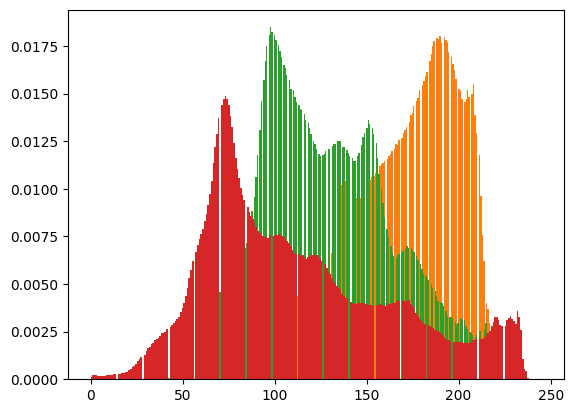

np.float64(0.0184863683127572)

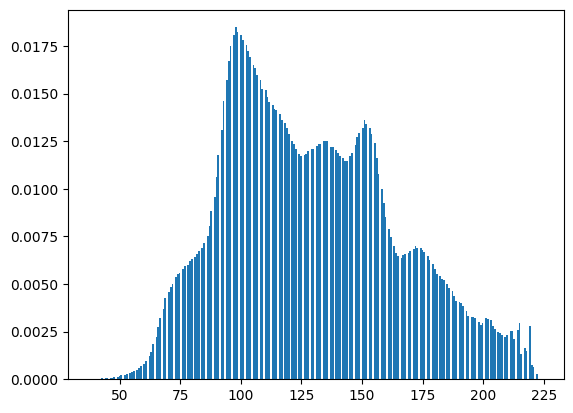

In [57]:
plt.hist(rgb[:, :, 0].ravel(), bins=256, density=True)
plt.hist(rgb[:, :, 0].ravel(), bins=256, density=True)
plt.hist(rgb[:, :, 1].ravel(), bins=256, density=True)
plt.hist(rgb[:, :, 2].ravel(), bins=256, density=True)
plt.show()
np.max(plt.hist(rgb[:, :, 1].ravel(), bins=256, density=True)[0])

In [58]:
rgb_n = rgb.copy()
rgb_n[:, :, 0] = (rgb[:, :, 0] - np.min(rgb[:, :, 0])) / (np.max(rgb[:, :, 0]) - np.min(rgb[:, :, 0])) * 255
rgb_n[:, :, 1] = (rgb[:, :, 1] - np.min(rgb[:, :, 1])) / (np.max(rgb[:, :, 1]) - np.min(rgb[:, :, 1])) * 255
rgb_n[:, :, 2] = (rgb[:, :, 2] - np.min(rgb[:, :, 2])) / (np.max(rgb[:, :, 2]) - np.min(rgb[:, :, 2])) * 255

In [59]:
rgb_n[891][1146]

array([184, 157, 152], dtype=uint8)

In [62]:
img_grey = cv2.cvtColor(rgb_n, cv2.COLOR_BGR2GRAY)
c = pywt.dwt2(img_grey, "haar")
ca, (ch, cv, cd) = c
ca1, (ch1, cv1, cd1) = pywt.dwt2(ca, "haar")
ca1[np.abs(ca1) < 90] = 0
np.count_nonzero(ca1 == 0)

286